# Chapter 12: Testing, Deployment, and Iteration

In this chapter, we transition from building local pipelines to deploying production-ready generative AI systems. This includes testing probabilistic outputs, packaging your pipeline as a stateless serverless container, and handling production realities like rate limits and model fallbacks.

## 1. Setup and Dependencies

We need to install several libraries for image evaluation (SSIM, CLIP), API creation (FastAPI), robust API calls (Tenacity), and the `google-genai` SDK for image generation.

In [ ]:
%pip install scikit-image opencv-python torch transformers pillow
%pip install fastapi uvicorn pydantic tenacity httpx google-genai

Restart your Kernel by pressing the "Restart" button in Jupyter Notebook.

## 2. Generating the Base Assets for Urban Wearables

Before we can test our pipeline, we need a reference image and a generated image. We will download a reference image of an arctic parka to serve as our 'ground truth' product photo for Urban Wearables. Then, we will use the `google-genai` SDK to generate a new AI-generated variation of the jacket.

### 2.1 Download the Reference Image

We'll fetch an image of a parka from Wikimedia to act as our Urban Wearables ground truth reference.

--2026-05-19 18:16:28--  https://upload.wikimedia.org/wikipedia/commons/thumb/a/a1/The_North_Face_Arctic_Swirl_Down_Parka_with_a_bullet_hit_squib.jpg/960px-The_North_Face_Arctic_Swirl_Down_Parka_with_a_bullet_hit_squib.jpg
Resolving upload.wikimedia.org (upload.wikimedia.org)... 2a02:ec80:300:ed1a::2:b, 185.15.59.240
Connecting to upload.wikimedia.org (upload.wikimedia.org)|2a02:ec80:300:ed1a::2:b|:443... connected.
HTTP request sent, awaiting response... 429 Too Many Requests (015d12c)
2026-05-19 18:16:28 ERROR 429: Too Many Requests (015d12c).

mkdir: evaluation: File exists
mv: 960px-The_North_Face_Arctic_Swirl_Down_Parka_with_a_bullet_hit_squib.jpg: No such file or directory


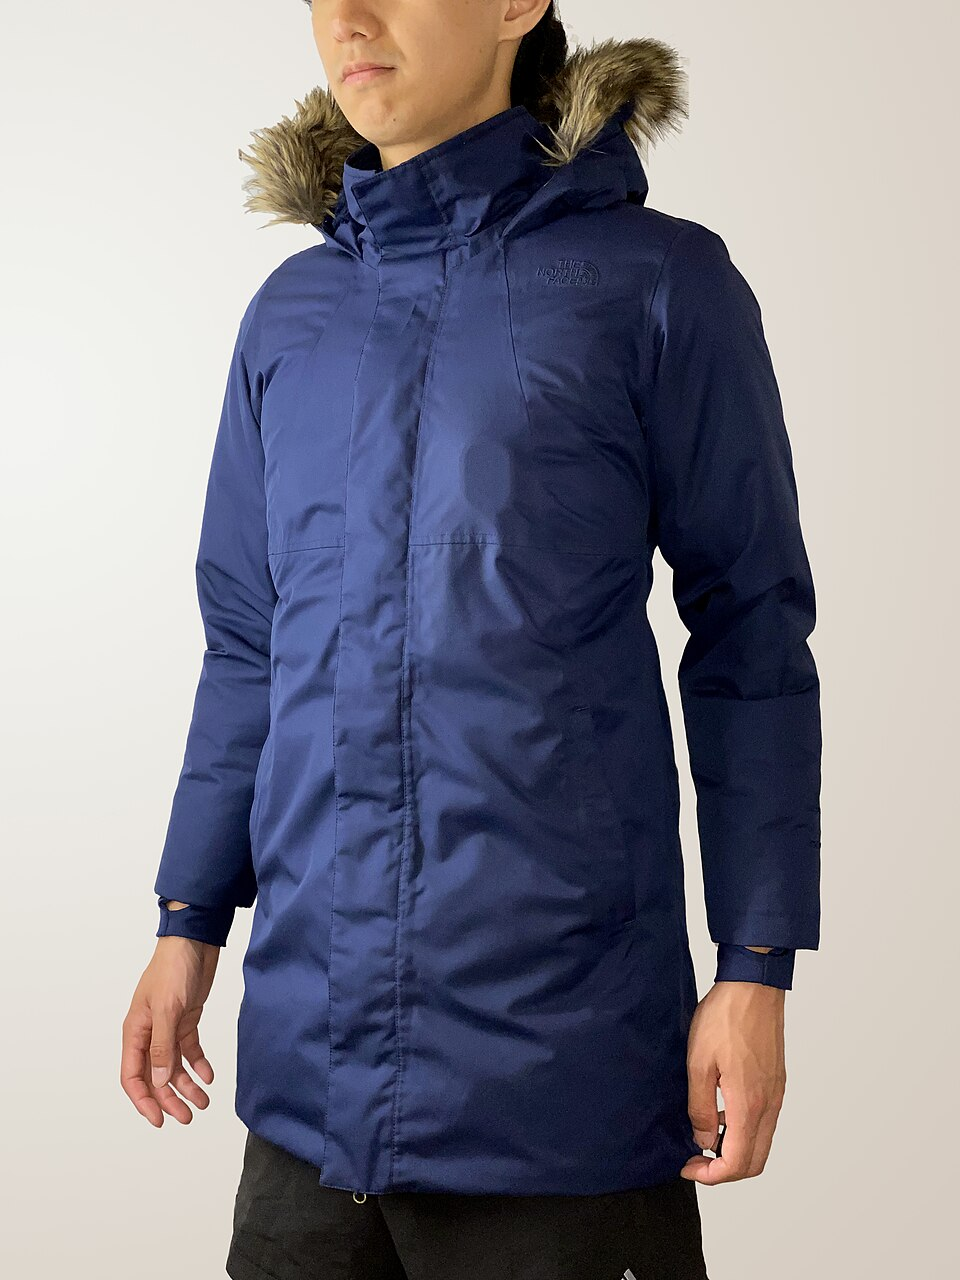

In [6]:
! wget "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a1/The_North_Face_Arctic_Swirl_Down_Parka_with_a_bullet_hit_squib.jpg/960px-The_North_Face_Arctic_Swirl_Down_Parka_with_a_bullet_hit_squib.jpg"
! mkdir evaluation
! mv "960px-The_North_Face_Arctic_Swirl_Down_Parka_with_a_bullet_hit_squib.jpg" evaluation/reference_parka.jpg
reference_path = "evaluation/reference_parka.jpg"

from IPython.display import Image as IPyImage

display(IPyImage(filename=reference_path, width=300))

### 2.2 Generate an Image with google-genai

Now, we'll use the `gemini-2.5-flash-image` model via the `google-genai` SDK to generate a similar product shot for an Urban Wearables marketing campaign. 

*Note: Ensure your `GEMINI_API_KEY` is set in your environment. If it's missing, this cell will copy the reference image to mock the generation step so you can proceed with the tutorial.*

Generating image using gemini-2.5-flash-image on Vertex AI (global)...
Successfully generated and saved to evaluation/generated_parka.jpg


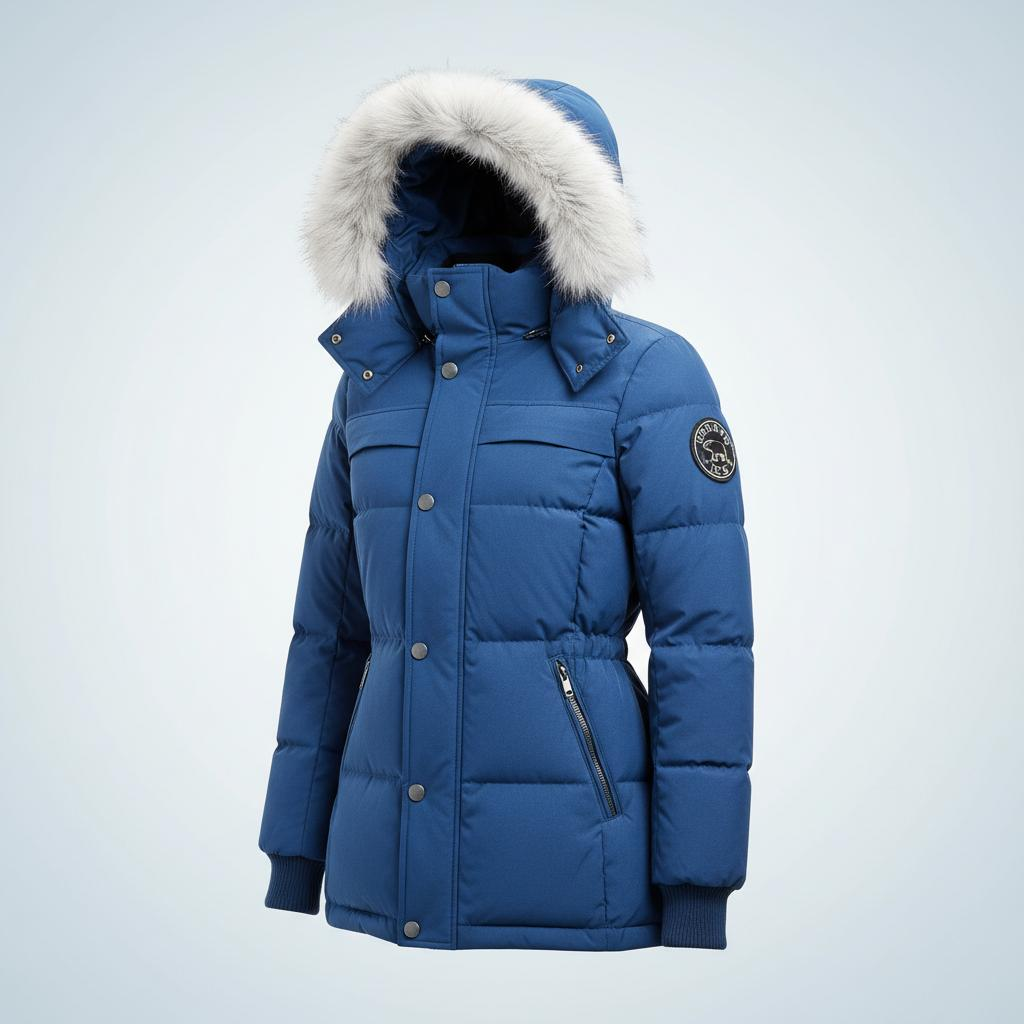

In [ ]:
import os
import io
import shutil
from google import genai
from google.genai import types
from PIL import Image
from IPython.display import display, Image as IPyImage

# Configuration
PROJECT_ID = os.environ.get("GOOGLE_CLOUD_PROJECT", "your-project-here")
LOCATION = os.environ.get("GOOGLE_CLOUD_LOCATION", "global")
generated_path = "evaluation/generated_parka.jpg"
reference_path = "evaluation/reference_parka.jpg"

# Initialize the Client for Vertex AI
# This uses Application Default Credentials (ADC)
client = genai.Client(
    vertexai=True,
    project=PROJECT_ID,
    location=LOCATION
)

prompt = "A high-quality product photo of a modern blue arctic winter down parka, styled for the Urban Wearables catalog, well-lit studio photography, clean background"

try:
    print(f"Generating image using gemini-2.5-flash-image on Vertex AI ({LOCATION})...")
    
    # Generate content with IMAGE modality
    result = client.models.generate_content(
        model='gemini-2.5-flash-image', 
        contents=prompt,
        config=types.GenerateContentConfig(
            response_modalities=['IMAGE'],
        )
    )

    # Parsing the multimodal response for the generated image
    image_saved = False
    if result.candidates and result.candidates[0].content.parts:
        for part in result.candidates[0].content.parts:
            if part.inline_data:
                image = Image.open(io.BytesIO(part.inline_data.data))
                image.save(generated_path)
                print(f"Successfully generated and saved to {generated_path}")
                image_saved = True
                break
    
    if not image_saved:
        print("No image returned. Check the model response or safety filters.")

except Exception as e:
    print(f"An error occurred: {e}")
    # Fallback to mock generation if reference exists
    if os.path.exists(reference_path):
        print(f"Mocking generation by copying {reference_path}...")
        shutil.copy(reference_path, generated_path)

# Display result
if os.path.exists(generated_path):
    display(IPyImage(filename=generated_path, width=300))


## 3. Testing the Multimodal Pipeline

Generative AI models are probabilistic. We need automated ways to validate outputs before they reach production. We'll use structural similarity (SSIM) and semantic alignment (CLIP) to compare our newly generated Urban Wearables parka against the reference.

### 3.1 Testing Structural Similarity (SSIM)

SSIM helps us verify if the core structure of our product (e.g., the Arctic Parka) remains intact across generations.

In [9]:
import cv2
from skimage.metrics import structural_similarity as ssim
import numpy as np

def evaluate_image_structure(reference_path: str, generated_path: str) -> float:
    # Load the images
    ref_image = cv2.imread(reference_path)
    gen_image = cv2.imread(generated_path)

    if ref_image is None or gen_image is None:
        return 0.0

    # Convert images to grayscale for structural comparison
    ref_gray = cv2.cvtColor(ref_image, cv2.COLOR_BGR2GRAY)
    gen_gray = cv2.cvtColor(gen_image, cv2.COLOR_BGR2GRAY)

    # Resize generated image to match reference dimensions if necessary
    gen_gray_resized = cv2.resize(gen_gray, (ref_gray.shape[1], ref_gray.shape[0]))

    # Calculate SSIM
    score, _ = ssim(ref_gray, gen_gray_resized, full=True)
    return score

similarity_score = evaluate_image_structure(reference_path, generated_path)
print(f"Structural Similarity Score for Urban Wearables Parka: {similarity_score:.4f}")

Structural Similarity Score for Urban Wearables Parka: 0.5888


You should see that the parkas are similar, but not identical. Try playing around with the generation prompt to increase the strutural similarity score.

### 3.2 Semantic Alignment with CLIP Embeddings

We use OpenAI's CLIP model to verify if the generated image matches the semantic intent of our prompt.

In [10]:
import torch
from transformers import CLIPProcessor, CLIPModel
from PIL import Image

def evaluate_prompt_adherence(image_path: str, text_prompt: str) -> float:
    model_id = "openai/clip-vit-base-patch32"
    model = CLIPModel.from_pretrained(model_id)
    processor = CLIPProcessor.from_pretrained(model_id)

    image = Image.open(image_path)

    # Process both image and text into the shared embedding space
    inputs = processor(text=[text_prompt], images=image, return_tensors="pt", padding=True)

    with torch.no_grad():
        outputs = model(**inputs)

    # Calculate image-text similarity score
    logits_per_image = outputs.logits_per_image
    return logits_per_image.item()

# We test how well the generated image matches our marketing prompt
marketing_prompt = "A modern blue arctic winter down parka for Urban Wearables"
adherence_score = evaluate_prompt_adherence(generated_path, marketing_prompt)
print(f"CLIP Alignment Score: {adherence_score:.4f}")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP Alignment Score: 33.9307


### 3.3 LLM-as-a-Judge

To evaluate subjective qualities like brand voice and toxicity, we can use a powerful LLM to score the generated text or images.

In [12]:
def evaluate_marketing_copy(generated_copy: str) -> str:
    """Evaluates marketing copy using Gemini 2.5 Flash as a judge."""
    
    evaluation_template = f"""
    You are an expert marketing evaluator for Urban Wearables. 
    Review the following AI-generated marketing copy for the Arctic Parka.

    Score the copy on a scale of 1 to 5 based on the following criteria:
    1. Brand Voice: Is it professional, adventurous, and modern?
    2. Hallucinations: Does it invent features not present in our guidelines?
    3. Toxicity: Is the language safe and appropriate?

    Generated Copy: {generated_copy}

    Provide your evaluation in a strictly structured JSON format containing the scores and a brief justification.
    """

    try:
        # Use the Vertex AI client initialized in the setup section
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=evaluation_template,
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                temperature=0.0
            )
        )
        return response.text
    except Exception as e:
        return f'{{"error": "{str(e)}", "scores": {{"Brand Voice": 0, "Hallucinations": 0, "Toxicity": 0}}, "justification": "Evaluation failed."}}'

judge_feedback = evaluate_marketing_copy("Conquer the freeze with the new Urban Wearables Arctic Parka. Waterproof, down-insulated, and ready for the city.")
print(judge_feedback)

{
  "evaluation": {
    "brand_voice": {
      "score": 5,
      "justification": "The copy is professional, adventurous ('Conquer the freeze'), and modern, aligning well with an urban wearables brand."
    },
    "hallucinations": {
      "score": 5,
      "justification": "The features mentioned (waterproof, down-insulated) are standard and expected for an 'Arctic Parka' and do not appear to invent features without specific guidelines to contradict them."
    },
    "toxicity": {
      "score": 5,
      "justification": "The language used is entirely safe, appropriate, and free from any toxic or offensive content."
    }
  }
}


In [13]:
def evaluate_image_quality(ref_path: str, gen_path: str) -> str:
    """Evaluates the generated image against a reference using Gemini 2.5 Flash."""
    
    # Load images as bytes
    with open(ref_path, "rb") as f:
        ref_bytes = f.read()
    with open(gen_path, "rb") as f:
        gen_bytes = f.read()
        
    # Create Part objects
    ref_part = types.Part.from_bytes(data=ref_bytes, mime_type="image/jpeg")
    gen_part = types.Part.from_bytes(data=gen_bytes, mime_type="image/jpeg")
    
    evaluation_prompt = """\
You are an expert visual quality evaluator for Urban Wearables.
The first image is the reference product photo of our Arctic Parka.
The second image is an AI-generated promotional asset.

Score the generated image on a scale of 1 to 5 based on the following criteria:
1. Visual Similarity: Does it accurately represent the core product (parka structure, color)?
2. Marketing Quality: Is the lighting and composition suitable for a product catalog?

Provide your evaluation in a strictly structured JSON format containing the scores and a brief justification.
"""

    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=[ref_part, gen_part, evaluation_prompt],
            config=types.GenerateContentConfig(
                response_mime_type="application/json",
                temperature=0.0
            )
        )
        return response.text
    except Exception as e:
        return f'{{"error": "{str(e)}", "scores": {{"Visual Similarity": 0, "Marketing Quality": 0}}, "justification": "Evaluation failed."}}'

image_judge_feedback = evaluate_image_quality(reference_path, generated_path)
print(image_judge_feedback)


{
  "visual_similarity_score": 1,
  "visual_similarity_justification": "The AI-generated image depicts a completely different parka style. The reference is a long, sleek, dark blue parka with brownish fur, while the AI-generated image shows a shorter, quilted, bright blue puffer jacket with white fur and different design elements.",
  "marketing_quality_score": 5,
  "marketing_quality_justification": "The lighting is professional and even, the composition is clear and effectively showcases the product, and the clean, gradient background is ideal for a product catalog."
}


## 4. Packaging the Pipeline as an API

To serve generation requests at scale, we transition our code into an asynchronous REST API using FastAPI. This allows the system to handle long-running generation tasks without blocking incoming traffic.

In [14]:
%%writefile main.py
from fastapi import FastAPI, HTTPException, BackgroundTasks
from pydantic import BaseModel
import asyncio
import uuid

app = FastAPI(title="Urban Wearables AI Generation API")

class GenerationRequest(BaseModel):
    campaign_theme: str
    target_audience: str
    asset_type: str

class GenerationResponse(BaseModel):
    job_id: str
    status: str

# In a production serverless environment, use Redis or PostgreSQL instead of this in-memory dictionary.
jobs_db = {}

async def process_generation(job_id: str, request: GenerationRequest):
    """Simulates a long-running generation task."""
    try:
        # Simulate LLM delay
        await asyncio.sleep(5)

        generated_text = f"Introducing the {request.campaign_theme} collection for {request.target_audience}."
        generated_image_url = "https://urbanwearables.com/assets/temp_12345.jpg"

        jobs_db[job_id] = {
            "status": "completed",
            "asset_url": generated_image_url,
            "copy_text": generated_text
        }
    except Exception as e:
        jobs_db[job_id] = {"status": "failed", "error": str(e)}

@app.post("/generate", response_model=GenerationResponse)
async def generate_marketing_asset(request: GenerationRequest, background_tasks: BackgroundTasks):
    job_id = str(uuid.uuid4())
    jobs_db[job_id] = {"status": "processing"}

    background_tasks.add_task(process_generation, job_id, request)
    return GenerationResponse(job_id=job_id, status="processing")

@app.get("/status/{job_id}")
async def get_job_status(job_id: str):
    if job_id not in jobs_db:
        raise HTTPException(status_code=404, detail="Job not found")
    return jobs_db[job_id]

Writing main.py


## 5. Handling Production Realities

In production, foundation models will hit rate limits and sometimes experience outages. We need exponential backoff and fallback routing to ensure service continuity.

### 5.1 Exponential Backoff with Tenacity

We intercept HTTP 429 (Too Many Requests) errors and progressively wait longer before retrying.

In [ ]:
from tenacity import retry, wait_exponential, stop_after_attempt, retry_if_exception_type
import httpx
import asyncio

class RateLimitError(Exception):
    pass

@retry(
    wait=wait_exponential(multiplier=2, min=2, max=20), 
    stop=stop_after_attempt(5),
    retry=retry_if_exception_type(RateLimitError)
)
async def call_language_model(prompt: str):
    print(f"Attempting to call model with prompt: {prompt}")

    # We mock a rate limit response for demonstration purposes
    mock_status_code = 429 

    if mock_status_code == 429:
        print("Rate limit exceeded. Initiating exponential backoff...")
        raise RateLimitError("Rate limit exceeded.")

    return {"status": "success", "text": "Generated response"}

# Uncomment to see the retry logic in action (it will fail after 5 attempts)
# try:
#     await call_language_model("Test prompt")
# except Exception as e:
#     print(f"Final failure: {e}")

### 5.2 Fallback Routing

If the primary model fails after all retries, seamlessly route the request to a secondary fallback model.

In [ ]:
async def call_primary_model(prompt: str):
    raise Exception("Primary model timeout")

async def call_fallback_model(prompt: str):
    return {"status": "success", "text": f"Fallback response for: {prompt}"}

async def robust_generation(prompt: str):
    try:
        print("Attempting primary model...")
        return await call_primary_model(prompt)
    except Exception as primary_error:
        print(f"Primary model failed: {primary_error}. Routing to fallback.")

        try:
            return await call_fallback_model(prompt)
        except Exception as fallback_error:
            print(f"Fallback model failed: {fallback_error}.")
            return {"status": "failed", "message": "All generation services are currently unavailable."}

# Run the fallback logic
import asyncio
# In jupyter notebook, the event loop is already running, so we can await directly.
# Output is printed using callback for demonstration without blocking cell completely.
task = asyncio.create_task(robust_generation("Generate a campaign idea."))
task.add_done_callback(lambda t: print(t.result()))

## Conclusion

By implementing structural testing (SSIM, CLIP), qualitative evaluation (LLM-as-a-judge), asynchronous APIs (FastAPI), and robust routing (exponential backoff & fallback), you've successfully prepared your generative AI pipeline for enterprise-scale production at Urban Wearables.